In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [2]:
import math

class Node:
    def __init__(self, value: float, parents=[]):
        """initialise le noeud a la valeur 'value'

        Args:
            value (float): valeur du noeud
            parents (list, optional): liste des parents du noeud. Defaults to [].
            
        _backward :
            but : avoir ∂(entré)/∂(sortie), proche en proche : ∂(entré)/∂(entré+1) * ∂(sortie-1)/∂(sortie)
            on note 'di' = ∂(sortie)/∂(noeud i) = `self.grad`
            
            Derive de proche en proche, noeud entré "a"->'da', sorti "b"->'db', avec b = f(a). En pratique f : ℝ^n -> ℝ^m
            init : db -> dJ, avec J noeud de sortie -> dJ = ∂(J)/∂J = 1
            recurence : suppose db connue 
            Donc on a: `a.grad` = da = ∂(J)/∂a = ∂(b)/∂(a) * ∂(J)/∂b or ∂(J)/∂b = db = `b.grad`
            et ∂(a)/∂(b) = derivé de la fonction du forward pass du noeud a->b, b=f(a). i.e. '+', '*' etc...
            Donc : a.grad = f'(a.value)*b.grad
            _backward definit le calcule de f' pour obtenir a.grad la valeur de f' en 1 point
            
            Si plusieur noeud fils on somme chaque branche -> '+='
        """
        self.value = value
        self.parents = parents
        self.grad = 0
        self._backward = lambda : None
         
    def __str__(self):
        return str(self.value)
       
    def __repr__(self):
        return f"Node(value={self.value}, grad={self.grad})"
        
    def __radd__(self, value):
        b = Node(self.value + value, parents=[self])
        def _backward():
            self.grad += b.grad
        b._backward = _backward
        return b 
        
    def __add__(self, b):
        """
        Gère l’opération self + b (supposé b un Node).
        Formule :
            f(x,y) = x + y
            ∂f/∂x = 1
            ∂f/∂y = 1
        """
        c = Node(self.value + b.value, parents=[self, b])
        def _backward():
            self.grad += c.grad
            b.grad += c.grad
        c._backward = _backward
        return c
    
    def __mul__(self, b):
        """
        Gère l’opération self * b (supposé b un Node).
        Formule :
            f(x,y) = x * y
            ∂f/∂x = y
            ∂f/∂y = x
        """
        c = Node(self.value * b.value, parents=[self, b])
        def _backward():
            self.grad += b.value * c.grad
            b.grad += self.value * c.grad
        c._backward = _backward
        return c
       
    def __rmul__(self, value):
        b = Node(self.value * value, parents=[self])
        def _backward():
            self.grad += value * b.grad
        b._backward = _backward
        return b 

    def __pow__(self, b):
        """
        Gère l’opération self ** b (supposé b un Node).
        Formule :
            f(x,y) = x^y = exp(y*ln(x))
            ∂f/∂x = y/x * x^y = y * x^(y-1)
            ∂f/∂y = x^y * ln(x)
        """
        c_value = self.value ** b.value
        c = Node(c_value, parents=[self, b])

        def _backward():
            # ∂(self^b) / ∂(self) = b * self^(b-1)
            # => contrib à self.grad = b.value * (self.value ** (b.value - 1)) * c.grad
            if self.value != 0:
                self.grad += b.value * (self.value ** (b.value - 1)) * c.grad
            else:
                # cas limite : 0^b (b > 1), dérivée wrt base est 0 sauf quelques cas particuliers
                self.grad += 0.0

            # ∂(self^b) / ∂b = self^b * ln(self)
            # => contrib à b.grad = (self.value ** b.value) * ln(self.value) * c.grad
            # Attention domaine : self.value > 0 pour ln
            if self.value > 0:
                b.grad += (self.value ** b.value) * math.log(self.value) * c.grad
            else:
                # si self.value <= 0 on évite ln négatif ou ln(0) : 
                # en pratique, on pourrait lever une exception pour indicer un domaine invalide
                b.grad += 0.0

        c._backward = _backward
        return c

    def __rpow__(self, base):
        a = float(base)
        # c = a ^ (self.value)
        c_value = a ** self.value
        c = Node(c_value, parents=[self])
        def _backward():
            # ∂(a^x)/∂x = a^x * ln(a)
            self.grad += (a ** self.value) * math.log(a) * c.grad
        c._backward = _backward
        return c
    
    def exp(self):
        """
        Gère l’opération exp(self).
        Formule :
            f(x) = exp(x)
            ∂f/∂x = exp(x)
        """
        b = Node(math.exp(self.value), parents=[self])
        def _backward():
            self.grad += b.value * b.grad
        b._backward =_backward
        return b

    def zero_grad(self):
        """
        Remet à zéro le champ `grad` pour ce nœud et pour tous ses ancêtres.
        Parcours récursif en profondeur (DFS) depuis self via `parents`.
        """
        visited = set()
        
        def dfs(node):
            if node not in visited:
                visited.add(node)
                for p in node.parents:
                    dfs(p)
        
        # On collecte tous les nœuds du sous‐graphe
        dfs(self)
        
        # Puis on remet grad à 0.0 pour chacun
        for n in visited:
            n.grad = 0.0

    def backward(self):
        """
        Propagera grad à tous les parents (ordre topologique inversé).
        On suppose que ce Node est la “sortie finale” et qu’on a déjà fixé self.grad = 1.0.
        """
        self.zero_grad()
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for parent in v.parents:
                    build_topo(parent)
                topo.append(v)

        build_topo(self)

        # On part du sommet (self) avec grad=1 et on propage dans l’ordre inverse
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [3]:
a = Node(3)
b = Node(4)

c = a + b
d = c * b

In [4]:
{
    "Entrée": (a, b),
    "Sortie": d,
} 
# avant backward, grad nul 

{'Entrée': (Node(value=3, grad=0), Node(value=4, grad=0)),
 'Sortie': Node(value=28, grad=0)}

In [5]:
d.backward()

In [6]:
a.grad, b.grad, c.grad, d.grad

(4.0, 11.0, 4.0, 1.0)

In [7]:
import numpy as np

def _sum_to(grad, shape):
    """Sum grad down to `shape`, undoing any numpy broadcasting."""
    while grad.ndim > len(shape):
        grad = grad.sum(axis=0)
    for axis, (s, g) in enumerate(zip(shape, grad.shape)):
        if s < g:
            grad = grad.sum(axis=axis, keepdims=True)
    return grad

class Node:
    def __init__(self, value, parents=[]):
        # Conversion en numpy array si nécessaire
        if not isinstance(value, (np.ndarray)):
            self.value = np.array(value, dtype=float)
        else:
            self.value = value.astype(float)
        
        self.parents = parents
        self.grad = np.zeros_like(self.value, dtype=float)
        self._backward = lambda: None

    def __repr__(self):
        return f"Node(value={self.value}\ngrad={self.grad})\n"

    def __add__(self, b):
        if not isinstance(b, Node):
            b = Node(b)
        # somme élément-wise ou broadcast
        c = Node(self.value + b.value, parents=[self, b])
        def _backward():
            self.grad += _sum_to(c.grad, self.grad.shape)
            b.grad += _sum_to(c.grad, b.grad.shape)
        
        c._backward = _backward
        return c

    def __radd__(self, b):
        return self.__add__(b)
    
    def __sub__(self, b):
        if not isinstance(b, Node):
            b = Node(b)
        c = Node(self.value - b.value, parents=[self, b])
        def _backward():
            self.grad += _sum_to(c.grad, self.grad.shape)
            b.grad -= _sum_to(c.grad, b.grad.shape)
        c._backward = _backward
        return c
    
    def __rsub__(self, b):
        if not isinstance(b, Node):
            b = Node(b)
        return b.__sub__(self)
    
    def __neg__(self):
        c = Node(-self.value, parents=[self])
        def _backward():
            self.grad -= c.grad
        c._backward = _backward
        return c

    def __matmul__(self, b):
        if not isinstance(b, Node):
            b = Node(b)

        c = Node(np.matmul(self.value, b.value), parents=[self, b])
        def _backward():
            self.grad += np.matmul(c.grad, b.value.T) # dA = dC B^T
            b.grad += np.matmul(self.value.T, c.grad) # dB = A^T dC
        c._backward = _backward
        return c
       
    def __mul__(self, b):
        if not isinstance(b, Node):
            b = Node(b)
        c = Node(self.value * b.value, parents=[self, b])
        def _backward():
            self.grad += _sum_to(b.value * c.grad, self.grad.shape)
            b.grad += _sum_to(self.value * c.grad, b.grad.shape)
        c._backward = _backward
        return c   
       
    def __rmul__(self, value): 
        b = Node(self.value * value, parents=[self])
        def _backward():
            self.grad += value * b.grad
        b._backward = _backward
        return b 

    def exp(self):
        b = Node(np.exp(self.value), parents=[self])
        def _backward():
            self.grad += np.multiply(b.value, b.grad)
        b._backward =_backward
        return b

    def log(self):
        b = Node(np.log(self.value), parents=[self])
        def _backward():
            self.grad += np.multiply(1 / self.value, b.grad)
        b._backward = _backward
        return b
    
    def relu(self):
        b = Node(np.maximum(0, self.value), parents=[self])
        def _backward():
            self.grad += np.where(self.value > 0, b.grad, 0)
        b._backward = _backward
        return b
    
    def mean(self):
        b = Node(self.value.mean(), parents=[self])
        def _backward():
            self.grad += (1 / self.value.size) * b.grad
        b._backward = _backward
        return b

    def sum(self):
        b = Node(self.value.sum(), parents=[self])
        def _backward():
            self.grad += b.grad
        b._backward = _backward
        return b
    
    def sigmoid(self):
        sig_value = 1 / (1 + np.exp(-self.value))
        b = Node(sig_value, parents=[self])
        def _backward():
            self.grad += np.multiply(sig_value * (1 - sig_value), b.grad)
        b._backward = _backward
        return b

    def backward(self):
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for parent in v.parents:
                    build_topo(parent)
                topo.append(v)
        build_topo(self)
        # gradient initial : 1 pour chaque élément
        self.grad = np.ones_like(self.value, dtype=float)
        for node in reversed(topo):
            node._backward()

    def zero_grad(self):
        visited = set()
        def dfs(node):
            if node not in visited:
                visited.add(node)
                for p in node.parents:
                    dfs(p)
        dfs(self)
        for n in visited:
            n.grad = np.zeros_like(n.value, dtype=float)
            
    def get_topological_order(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for parent in v.parents:
                    build_topo(parent)
                topo.append(v)
        build_topo(self)
        return reversed(topo)


In [8]:
# ── 1. Synthetic dataset ───────────────────────────────────────────
rng = np.random.default_rng(42)
n = 100                               # samples
X = rng.normal(size=(n, 2))          # 2 features
w_true = np.array([1.5, -2.0])
b_true = np.array(0.5)
logits = X @ w_true + b_true
y = (logits > 0).astype(float)   # binary labels

In [9]:
def forward(X, W, b):
    return X @ W + b

def cross_entropy(logits, y):
    yhat = logits.sigmoid()
    # Binary cross-entropy loss
    ones = Node(np.ones_like(y.value))
    loss = - (y * yhat.log() + (ones - y) * (ones - yhat).log()).mean()
    return loss

def opt_step(W, b, lr):
    # Update parameters
    W.value -= lr * W.grad
    b.value -= lr * b.grad
    return W, b

In [10]:
def train(X, y, W, b, lr=0.1, epochs=200):
    losses = [] 
    for epoch in range(epochs):
        logits = forward(X, W, b)
        loss = cross_entropy(logits, y)
        loss.zero_grad()  # reset gradients before backward pass
        loss.backward()
        W, b = opt_step( W, b, lr)
        losses.append(loss.value)
        if epoch % 10 == 0:
            # eval on training set
            yhat = forward(X, W, b).sigmoid().value
            y_pred = (yhat > 0.5).astype(float)
            accuracy = (y_pred == y.value).mean()
            print(f"Epoch {epoch}, Loss: {loss.value:.4f} Accuracy: {accuracy:.4f}")

    return W, b, losses

W = Node(rng.normal(size=(2,1)) * 0.01)
b = Node([0.0])
W_trained, b_trained, losses = train(Node(X), Node(y.reshape(-1, 1)), W, b)

Epoch 0, Loss: 0.6966 Accuracy: 0.8500
Epoch 10, Loss: 0.5974 Accuracy: 0.9200
Epoch 20, Loss: 0.5272 Accuracy: 0.9200
Epoch 30, Loss: 0.4756 Accuracy: 0.9300
Epoch 40, Loss: 0.4364 Accuracy: 0.9400
Epoch 50, Loss: 0.4056 Accuracy: 0.9500
Epoch 60, Loss: 0.3807 Accuracy: 0.9500
Epoch 70, Loss: 0.3600 Accuracy: 0.9500
Epoch 80, Loss: 0.3427 Accuracy: 0.9500
Epoch 90, Loss: 0.3278 Accuracy: 0.9600
Epoch 100, Loss: 0.3148 Accuracy: 0.9600
Epoch 110, Loss: 0.3035 Accuracy: 0.9600
Epoch 120, Loss: 0.2934 Accuracy: 0.9700
Epoch 130, Loss: 0.2844 Accuracy: 0.9700
Epoch 140, Loss: 0.2763 Accuracy: 0.9700
Epoch 150, Loss: 0.2689 Accuracy: 0.9700
Epoch 160, Loss: 0.2622 Accuracy: 0.9700
Epoch 170, Loss: 0.2560 Accuracy: 0.9700
Epoch 180, Loss: 0.2503 Accuracy: 0.9700
Epoch 190, Loss: 0.2451 Accuracy: 0.9700


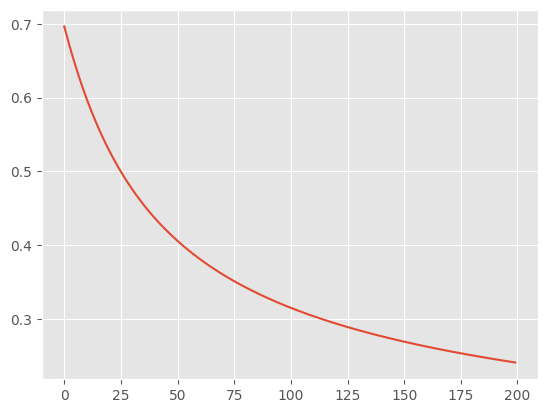

In [11]:
plt.plot(losses)

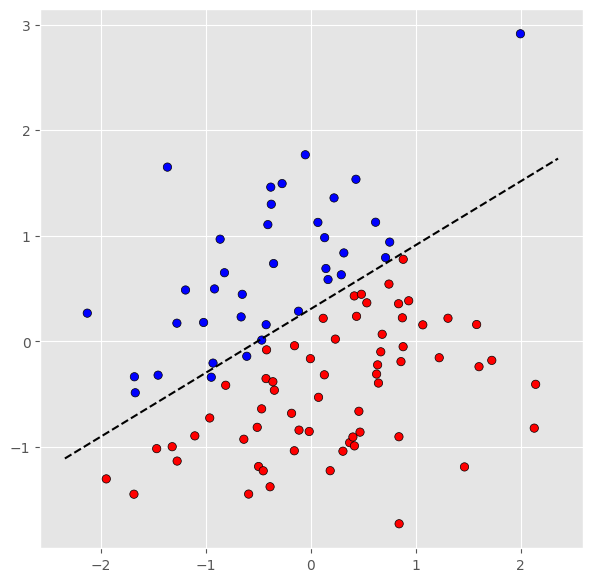

In [12]:
plt.figure(figsize=(7, 7))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k')
# decision boundaries: w[0]*x1 + w[1]*x2 + b = 0 => x2 = -(w[0]*x1 + b) / w[1]
x_vals = np.array(plt.gca().get_xlim())
p = - (W_trained.value[0] * x_vals + b_trained.value) / W_trained.value[1]
plt.plot(x_vals, p, 'k--')
